# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")


# Model architecture

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import random
import pickle
import json

# --- Dataset ---
class SensorDataset(Dataset):
    def __init__(self, sensor_seqs, tabular_feats, labels):
        self.sensor_seqs = torch.tensor(sensor_seqs, dtype=torch.float32)
        self.tabular_feats = torch.tensor(tabular_feats, dtype=torch.float32)
        if isinstance(labels, pd.Series):
            self.labels = torch.tensor(labels.values, dtype=torch.long)
        else:
            self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_seqs[idx], self.tabular_feats[idx], self.labels[idx]

# --- Transformer Model ---
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=6, seq_len=128, n_heads=4, num_layers=2,
                 d_model=64, dim_feedforward=128, tabular_dim=3,
                 tab_hidden_dim=32, output_dim=12, dropout=0.3):
        super(TransformerClassifier, self).__init__()

        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model + tab_hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_seq, x_tab):
        x = self.input_proj(x_seq)
        x = self.transformer_encoder(x)
        x_last = x[:, -1, :]
        tab_out = self.tabular_net(x_tab)
        combined = torch.cat((x_last, tab_out), dim=1)
        return self.classifier(combined)

# --- Training ---
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_seq, x_tab, y in dataloader:
        x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x_seq, x_tab)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_f1(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return f1_score(all_labels, all_preds, average='weighted')

# --- Hyperparameter Search ---
param_space = {
    'hidden_dim': [64, 128],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.3, 0.5],
    'tab_hidden_dim': [16, 32, 64],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128]
}

def sample_hyperparams(param_space):
    return {k: random.choice(v) for k, v in param_space.items()}

def run_random_search_cv(sensor_data, tab_data, labels, num_trials=10, num_epochs=10, device='cuda'):
    best_f1 = -1
    best_params = None
    best_model_state = None

    for trial in range(num_trials):
        print(f"\nTrial {trial+1}/{num_trials}")
        params = sample_hyperparams(param_space)
        print("Params:", params)

        all_f1_scores = []
        for split in range(10):
            X_tr, X_val, T_tr, T_val, y_tr, y_val = train_test_split(
                sensor_data, tab_data, labels,
                test_size=0.2, stratify=labels, random_state=split + trial * 100
            )

            train_ds = SensorDataset(X_tr, T_tr, y_tr)
            val_ds = SensorDataset(X_val, T_val, y_val)
            train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=0)
            val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False, num_workers=0)


            model = TransformerClassifier(
                input_dim=sensor_data.shape[2],
                seq_len=sensor_data.shape[1],
                n_heads=4,
                num_layers=params['num_layers'],
                d_model=params['hidden_dim'],
                dim_feedforward=128,
                tabular_dim=tab_data.shape[1],
                tab_hidden_dim=params['tab_hidden_dim'],
                output_dim=len(np.unique(labels)),
                dropout=params['dropout']
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
            criterion = nn.CrossEntropyLoss()

            best_val_f1 = 0
            patience = 5
            patience_counter = 0

            for epoch in range(num_epochs):
                train_one_epoch(model, train_loader, optimizer, criterion, device)
                f1 = evaluate_f1(model, val_loader, device)

                if f1 > best_val_f1:
                    best_val_f1 = f1
                    best_epoch_model = model.state_dict()
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break

            model.load_state_dict(best_epoch_model)
            f1 = evaluate_f1(model, val_loader, device)
            all_f1_scores.append(f1)

        avg_f1 = np.mean(all_f1_scores)
        print(f"Average F1 score: {avg_f1:.4f}")

        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_params = params
            best_model_state = model.state_dict()
            torch.save(best_model_state, "AUG_TRANSFORMER_BEST_MODEL.pth")

            with open("AUG_TRANSFORMER_BEST_PARAMS.pickle", "wb") as f:
                pickle.dump(best_params, f)

            with open("AUG_TRANSFORMER_BEST_PARAMS.json", "w") as f:
                json.dump(best_params, f, indent=4)

    print("\nBest Hyperparameters Found:")
    print(best_params)
    print(f"Best Average F1: {best_f1:.4f}")
    return best_params, best_f1, best_model_state


# Load libraries, set seed and Data preprocessing

C:\Users\anuhe\AppData\Local\Temp\ipykernel_21620\989979656.py:24: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_21620\989979656.py:24: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct

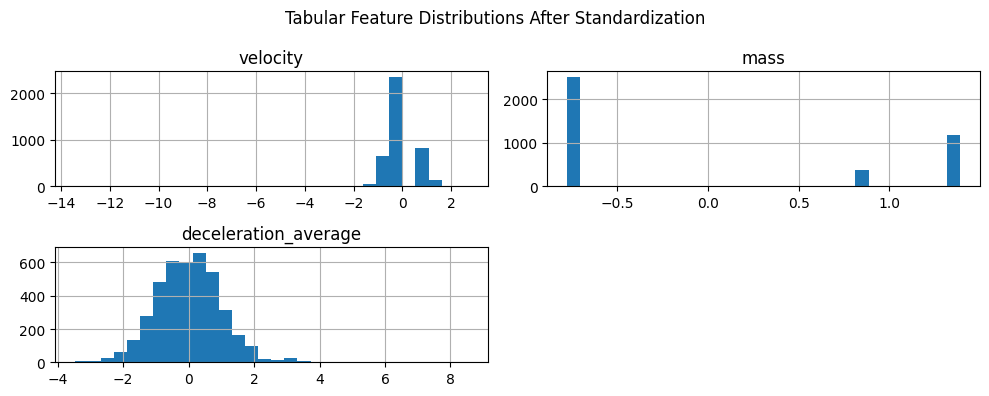

          Component            Shape
0       Sensor Data  (14998, 128, 6)
1  Tabular Features       (14998, 3)
2            Labels         (14998,)


In [ ]:
import torch
import pickle
import numpy as np
import random
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
import matplotlib.pyplot as plt

# --- Set random seed ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


# def load_pickle(path):
#     with open(path, 'rb') as f:
#         return pickle.load(f)
# # Load and prepare data
# train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
# test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")


train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

# --- KNN Imputation for test_data ---
combined = pd.concat([train_data.drop(columns=["label"]), test_data.drop(columns=["label"])]).reset_index(drop=True)
knn_imputer = KNNImputer(n_neighbors=5)
combined_imputed = knn_imputer.fit_transform(combined.select_dtypes(include=[np.number]))

# Restore imputed test_data
combined_columns = combined.select_dtypes(include=[np.number]).columns
test_data.loc[:, combined_columns] = combined_imputed[len(train_data):, :]

# --- Feature Splitting ---
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)

X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

# --- Tabular Standardization ---
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

# --- Visualize standardized tabular data ---
tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()

# --- Sensor Standardization ---
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

sensor_scaler = RobustScaler()
flat_train_scaled = sensor_scaler.fit_transform(flat_train)
flat_test_scaled = sensor_scaler.transform(flat_test)

X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)

# --- Data Augmentation ---
def augment_sensor_data(X_sensor, y, target_class, n_aug):
    idx = np.where(y == target_class)[0]
    augmented = []
    for _ in range(n_aug):
        sample = X_sensor[np.random.choice(idx)].copy()
        sample += np.random.normal(0, 0.01, sample.shape)
        factor = np.random.uniform(0.9, 1.1, (1, sample.shape[1]))
        sample *= factor
        segs = np.array_split(sample, 4)
        np.random.shuffle(segs)
        sample = np.concatenate(segs, axis=0)
        augmented.append(sample)
    return np.array(augmented), np.full(n_aug, target_class)

def augment_tabular_features(X_tab, y_tab, y_aug, noise_std=0.05):
    X_aug_tab = []
    for label in y_aug:
        class_samples = X_tab[y_tab == label]
        sample = class_samples[np.random.randint(len(class_samples))]
        noise = np.random.normal(0, noise_std, size=sample.shape)
        X_aug_tab.append(sample + noise)
    return np.array(X_aug_tab)

def augment_dataset(X_sensor, X_tab, y, target_count=500):
    unique_classes, class_counts = np.unique(y, return_counts=True)
    X_sensor_aug_all, y_aug_all = [], []

    for cls, count in zip(unique_classes, class_counts):
        n_needed = target_count - count
        if n_needed > 0:
            X_sensor_aug, y_aug = augment_sensor_data(X_sensor, y, cls, n_needed)
            X_sensor_aug_all.append(X_sensor_aug)
            y_aug_all.append(y_aug)

    if not X_sensor_aug_all:
        return X_sensor, X_tab, y

    X_sensor_aug = np.concatenate(X_sensor_aug_all)
    y_aug = np.concatenate(y_aug_all)
    X_tab_aug = augment_tabular_features(X_tab, y, y_aug)

    X_sensor_balanced = np.concatenate([X_sensor, X_sensor_aug])
    X_tab_balanced = np.vstack([X_tab, X_tab_aug])
    y_balanced = np.concatenate([y, y_aug])

    return X_sensor_balanced, X_tab_balanced, y_balanced

# --- Apply augmentation ---
X_train_sensor_balanced, X_train_tab_balanced, y_train_balanced = augment_dataset(
    X_sensor=X_train_sensor_clipped,
    X_tab=X_train_tab_scaled,
    y=y_train.values,
    target_count=1200
)

# --- Summary ---
sensor_shape = X_train_sensor_balanced.shape
tabular_shape = X_train_tab_balanced.shape
label_shape = y_train_balanced.shape

summary_df = pd.DataFrame({
    "Component": ["Sensor Data", "Tabular Features", "Labels"],
    "Shape": [sensor_shape, tabular_shape, label_shape]
})

print(summary_df)


# Train model

In [11]:
if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    best_params, best_f1, best_model_state = run_random_search_cv(
        sensor_data=X_train_sensor_balanced,
        tab_data=X_train_tab_balanced,
        labels=y_train_balanced,
        num_trials=2,      # adjust for test
        num_epochs=10,
        device=device
    )



Trial 1/2
Params: {'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.5, 'tab_hidden_dim': 32, 'learning_rate': 0.0001, 'batch_size': 32}
Average F1 score: 0.9741

Trial 2/2
Params: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.1, 'tab_hidden_dim': 64, 'learning_rate': 0.001, 'batch_size': 128}
Early stopping at epoch 10
Early stopping at epoch 10
Early stopping at epoch 9
Average F1 score: 0.9983

Best Hyperparameters Found:
{'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.1, 'tab_hidden_dim': 64, 'learning_rate': 0.001, 'batch_size': 128}
Best Average F1: 0.9983


# Load Best model and test loader and evaluation

In [3]:
best_params = {
    'hidden_dim': 64,
    'num_layers': 3,
    
    'dropout': 0.1,
    'tab_hidden_dim': 64,
    'learning_rate': 0.001,
    'batch_size': 128
}
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Load the best saved model
model = TransformerClassifier(
    input_dim=X_test_sensor_clipped.shape[2],
    seq_len=X_test_sensor_clipped.shape[1],
    n_heads=4,
    num_layers=best_params['num_layers'],
    d_model=best_params['hidden_dim'],
    dim_feedforward=128,
    tabular_dim=X_test_tab_scaled.shape[1],
    tab_hidden_dim=best_params['tab_hidden_dim'],
    output_dim=len(np.unique(y_train_balanced)),
    dropout=best_params['dropout']
).to(device)

model.load_state_dict(torch.load("AUG_TRANSFORMER_BEST_MODEL.pth"))

# Create test dataset and loader
test_dataset = SensorDataset(X_test_sensor_clipped, X_test_tab_scaled, y_test)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False, num_workers=0)

# Evaluate
test_f1 = evaluate_f1(model, test_loader, device)
print(f"F1 score on test set: {test_f1:.4f}")


F1 score on test set: 0.4240


# Confusion matrix normalized

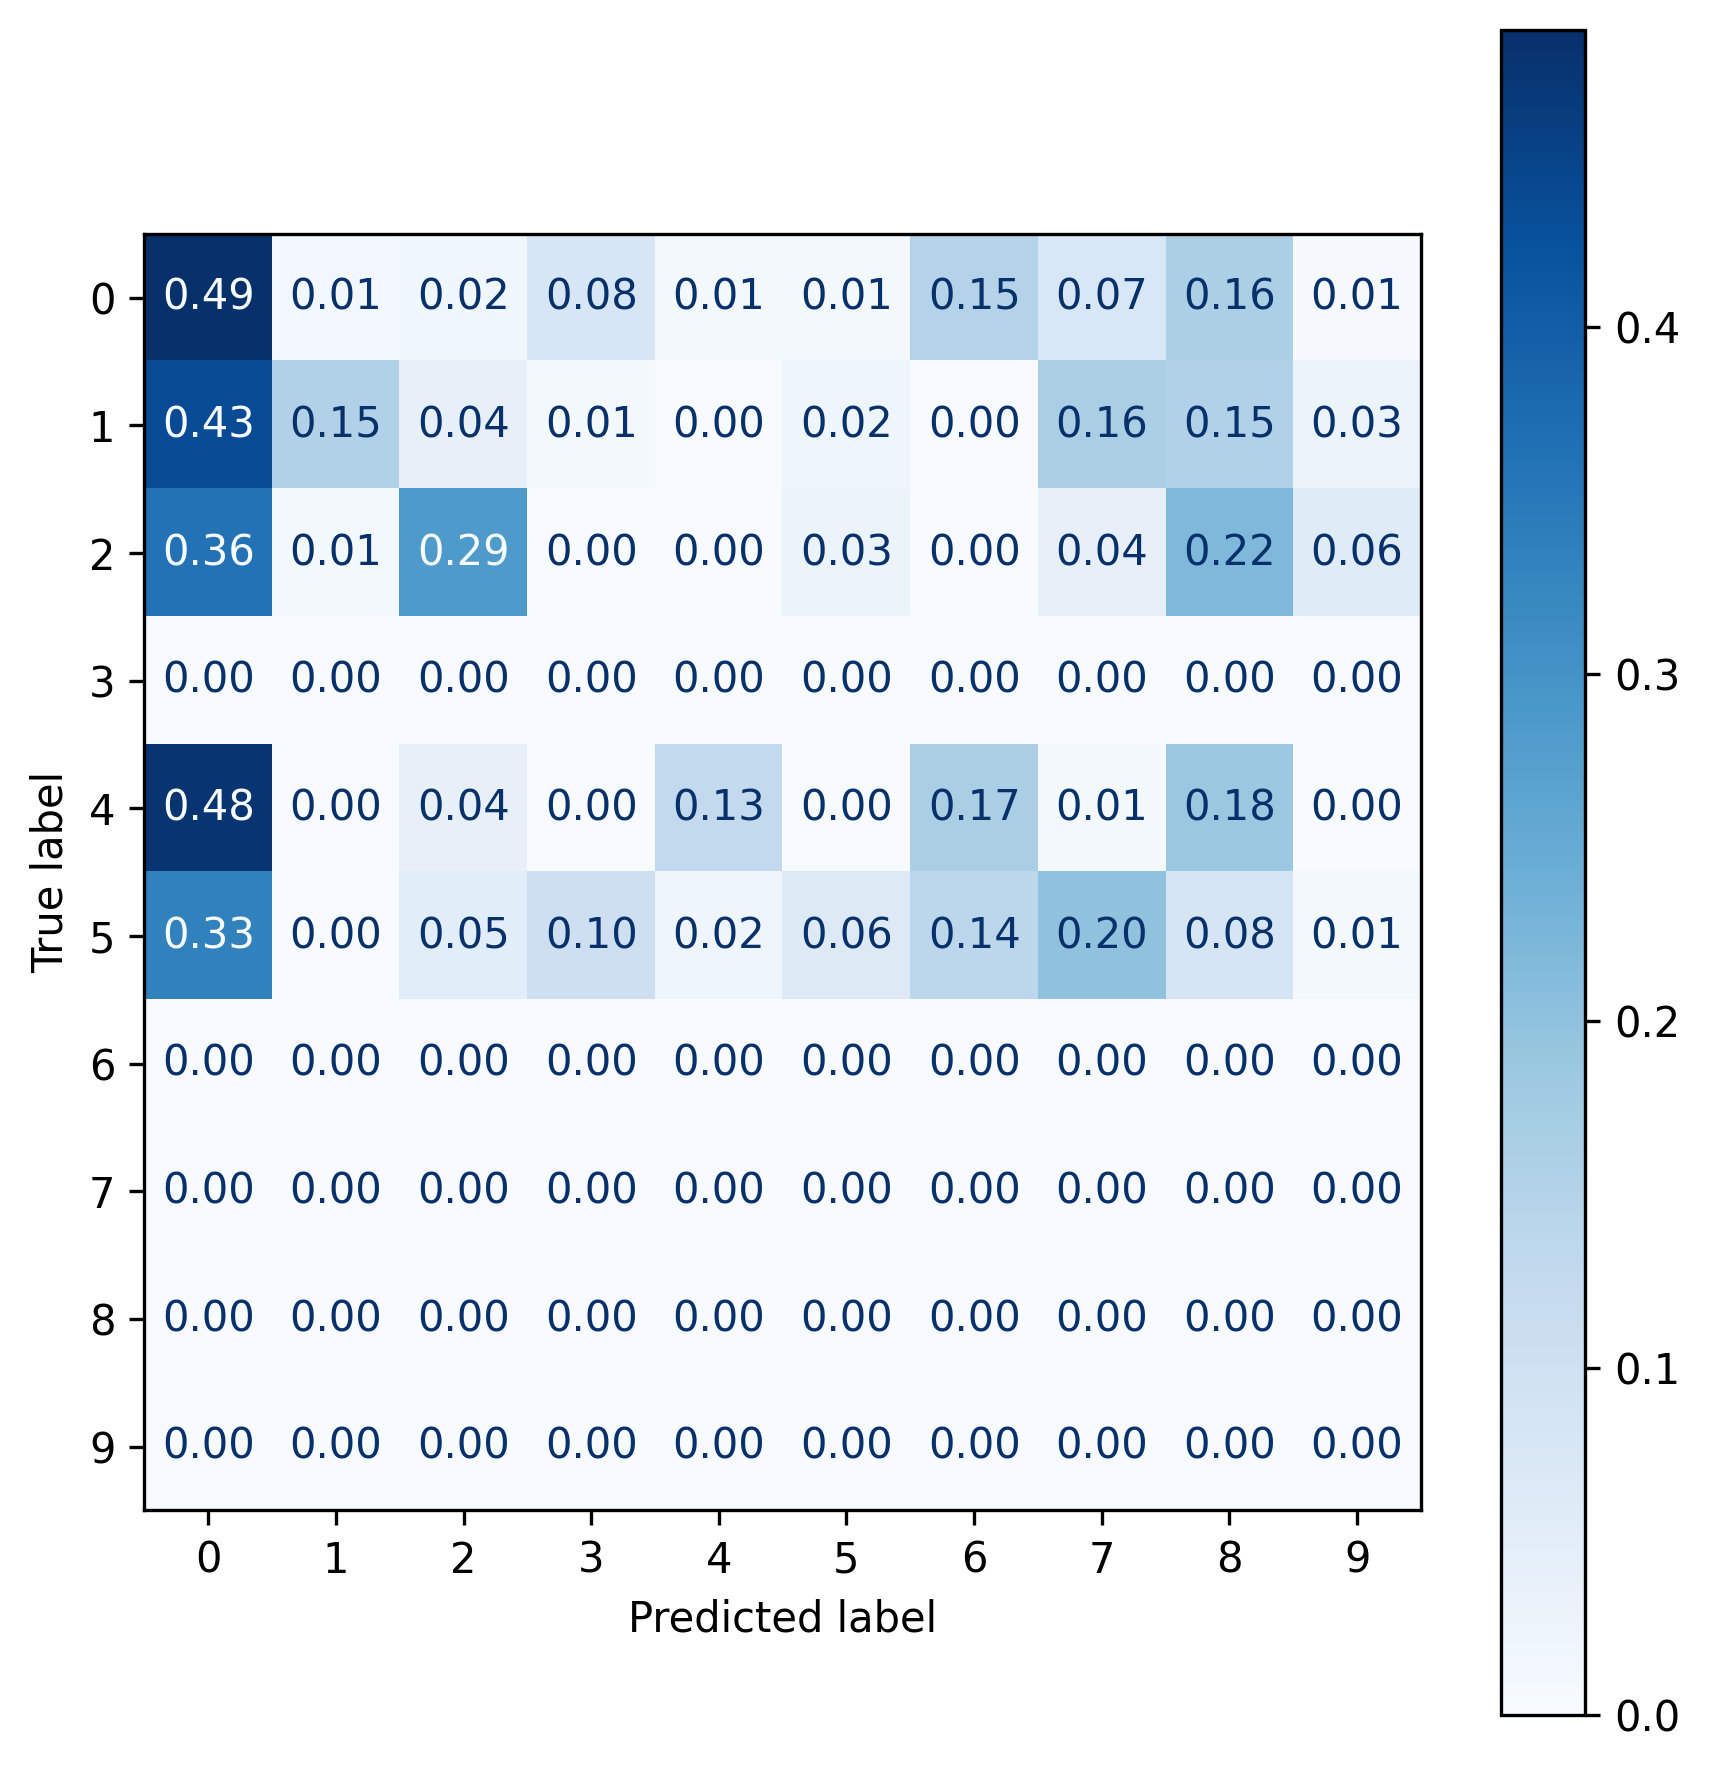

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === Step 1: Get predictions and labels ===
def get_preds_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for sensor_data, tabular_data, labels in dataloader:
            sensor_data = sensor_data.to(device)
            tabular_data = tabular_data.to(device)
            labels = labels.to(device)

            outputs = model(sensor_data, tabular_data)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return all_preds, all_labels

# === Step 2: Evaluate and compute confusion matrix ===
preds, labels = get_preds_and_labels(model, test_loader, device)

# Normalized confusion matrix
cm = confusion_matrix(labels, preds, normalize='true')

# === Step 3: Filter out classes with both row AND column = 0 ===
non_zero_rows = ~np.all(cm == 0, axis=1)
non_zero_cols = ~np.all(cm == 0, axis=0)
valid_indices = np.logical_or(non_zero_rows, non_zero_cols)  # keep if row OR col is non-zero

cm_filtered = cm[np.ix_(valid_indices, valid_indices)]
class_labels = np.arange(cm.shape[0])[valid_indices]  # update class labels accordingly

# === Step 4: Plot the confusion matrix ===
disp = ConfusionMatrixDisplay(confusion_matrix=cm_filtered, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp.plot(cmap=plt.cm.Blues, values_format=".2f", ax=ax)

#plt.title("Normalized Confusion Matrix Transformer")
plt.tight_layout()

# Optional: Save the figure
# fig.savefig("your_path/confusion_filtered.jpg", dpi=300)
fig.savefig("C:/Study and work/Sem 6/Neural Networks, Deep Learning and Applications/Report/Transformer_case9.jpg", dpi=300)
plt.show()
